# Data Exploration
## Anscombe's Quartet
The following code is adapted from https://matplotlib.org/stable/gallery/specialty_plots/anscombe.html.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
from sklearn.model_selection import train_test_split

In [2]:
x = np.array([10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5])
y1 = np.array([8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68])
y2 = np.array([9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74])
y3 = np.array([7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73])
x4 = np.array([8, 8, 8, 8, 8, 8, 8, 19, 8, 8, 8])
y4 = np.array([6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89])

datasets = {
    'I': (x, y1),
    'II': (x, y2),
    'III': (x, y3),
    'IV': (x4, y4)
}

In [3]:
# look at mean, stdev, corr coeff
for label, (x,y) in datasets.items():
    print(f"Dataset {label}:")
    print(f"  Mean:  {np.mean(y):.2f}")
    print(f"  Stdev: {np.std(y):.2f}")
    print(f"  R^2: {np.corrcoef(x,y)[0][1]**2:.2f}")
    # print(f"  Min: {np.min(y):.2f}")
    # print(f"  Max: {np.max(y):.2f}")

Dataset I:
  Mean:  7.50
  Stdev: 1.94
  R^2: 0.67
Dataset II:
  Mean:  7.50
  Stdev: 1.94
  R^2: 0.67
Dataset III:
  Mean:  7.50
  Stdev: 1.94
  R^2: 0.67
Dataset IV:
  Mean:  7.50
  Stdev: 1.94
  R^2: 0.67


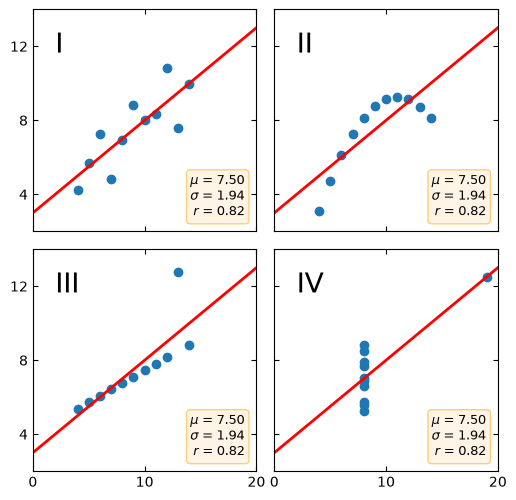

In [4]:

fig, axs = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(6, 6),
                        gridspec_kw={'wspace': 0.08, 'hspace': 0.08})
axs[0, 0].set(xlim=(0, 20), ylim=(2, 14))
axs[0, 0].set(xticks=(0, 10, 20), yticks=(4, 8, 12))

for ax, (label, (x, y)) in zip(axs.flat, datasets.items()):
    ax.text(0.1, 0.9, label, fontsize=20, transform=ax.transAxes, va='top')
    ax.tick_params(direction='in', top=True, right=True)
    ax.plot(x, y, 'o')

    # linear regression
    p1, p0 = np.polyfit(x, y, deg=1)  # slope, intercept
    ax.axline(xy1=(0, p0), slope=p1, color='r', lw=2)

    # add text box for the statistics
    stats = (f'$\\mu$ = {np.mean(y):.2f}\n'
             f'$\\sigma$ = {np.std(y):.2f}\n'
             f'$r$ = {np.corrcoef(x, y)[0][1]:.2f}')
    bbox = dict(boxstyle='round', fc='blanchedalmond', ec='orange', alpha=0.5)
    ax.text(0.95, 0.07, stats, fontsize=9, bbox=bbox,
            transform=ax.transAxes, horizontalalignment='right')

plt.show()

## Datasaurus Dozen
From https://www.research.autodesk.com/publications/same-stats-different-graphs/

In [5]:
# load the dataset
dsd = pd.read_csv("DatasaurusDozen.tsv", sep="\t")
dsd.head()

,dataset,x,y
0,dino,55.3846,97.1795
1,dino,51.5385,96.0256
2,dino,46.1538,94.4872
3,dino,42.8205,91.4103
4,dino,40.7692,88.3333


In [6]:
dsd.info()

<class 'pandas.DataFrame'>
RangeIndex: 1846 entries, 0 to 1845
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   dataset  1846 non-null   str    
 1   x        1846 non-null   float64
 2   y        1846 non-null   float64
dtypes: float64(2), str(1)
memory usage: 43.4 KB


In [7]:
dsd["dataset"].value_counts()

dataset
dino          142
away          142
h_lines       142
v_lines       142
x_shape       142
star          142
high_lines    142
dots          142
circle        142
bullseye      142
slant_up      142
slant_down    142
wide_lines    142
Name: count, dtype: int64

Dataset dino:
  Mean:  47.83
  Stdev: 26.84
  R^2: 0.00
Dataset away:
  Mean:  47.83
  Stdev: 26.84
  R^2: 0.00
Dataset h_lines:
  Mean:  47.83
  Stdev: 26.84
  R^2: 0.00
Dataset v_lines:
  Mean:  47.84
  Stdev: 26.84
  R^2: 0.00
Dataset x_shape:
  Mean:  47.84
  Stdev: 26.84
  R^2: 0.00
Dataset star:
  Mean:  47.84
  Stdev: 26.84
  R^2: 0.00
Dataset high_lines:
  Mean:  47.84
  Stdev: 26.84
  R^2: 0.00
Dataset dots:
  Mean:  47.84
  Stdev: 26.84
  R^2: 0.00
Dataset circle:
  Mean:  47.84
  Stdev: 26.84
  R^2: 0.00
Dataset bullseye:
  Mean:  47.83
  Stdev: 26.84
  R^2: 0.00
Dataset slant_up:
  Mean:  47.83
  Stdev: 26.84
  R^2: 0.00
Dataset slant_down:
  Mean:  47.84
  Stdev: 26.84
  R^2: 0.00


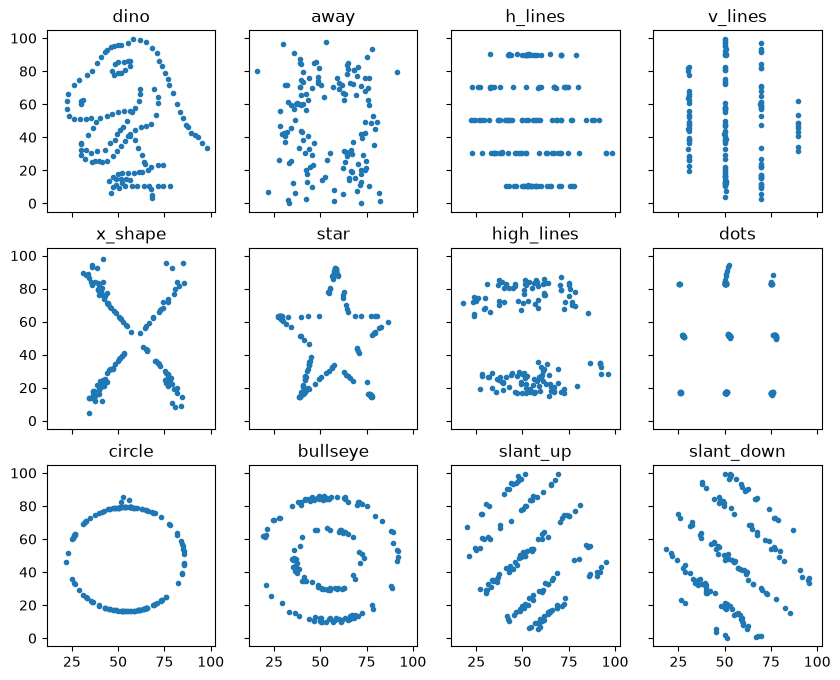

In [9]:
fig, axs = plt.subplots(3, 4, sharex=True, sharey=True, figsize=(10,8))

for ax, name in zip(axs.flat, dsd["dataset"].unique()):
    slice = dsd.query("dataset == @name")
    ax.scatter(slice["x"], slice["y"], marker=".")
    ax.set_title(name)

    print(f"Dataset {name}:")
    print(f"  Mean:  {np.mean(slice['y']):.2f}")
    print(f"  Stdev: {np.std(slice['y']):.2f}")
    print(f"  R^2: {np.corrcoef(slice['x'],slice['y'])[0][1]**2:.2f}")

# A more useful example
Let's revisit Kaggle's [Titanic dataset](https://www.kaggle.com/competitions/titanic/data). Kaggle has already split the data into train/test, so we'll just load the training data and pretend that test doesn't exist.

Many public datasets are pre-split. This is so that you can replicate published results exactly. In other cases (like Kaggle competitions), a final test set is kept secret, ensuring things really can't leak.

In [10]:
td = pd.read_csv("titanic_train.csv")

In [13]:
# TODO: info, describe, head
td.info()
td.describe()
td.head(n=10)

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [14]:
# Do more women survive than men? "Women and children first"
td[["Sex", "Survived"]].groupby("Sex").value_counts()

Sex     Survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64

Text(0, 0.5, '# of people')

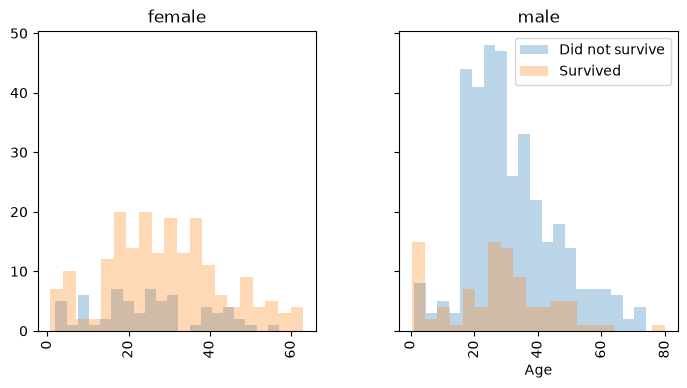

In [15]:
# What about the relationship between age and survival?
ax = td[td["Survived"] == 0].hist(by="Sex", column="Age", figsize=(8,4), alpha=0.3, label="Did not survive", sharey=True, bins=20)
td[td["Survived"] == 1].hist(ax=ax, by="Sex", column="Age", figsize=(8,4), alpha=0.3, label="Survived", bins=20)
plt.legend()
plt.xlabel("Age")
plt.ylabel("# of people")

<Axes: xlabel='Age', ylabel='Fare'>

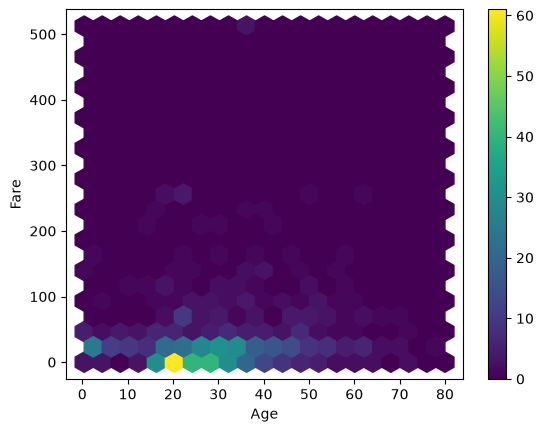

In [ ]:
# is there a relationship between fare and age?
td.plot.scatter(x="Age", y="Fare", c="Survived", cmap="viridis", alpha=0.3)

# great if you have a huge number of samples
#td.plot.hexbin(x="Age", y="Fare", cmap="viridis", gridsize=20) 

## Splitting the data

In [ ]:
# Splitting the data - random sample
# at minimum, needs random seed for consistency
td_train, td_test = train_test_split(td, test_size=0.2, random_state=1234)

In [ ]:
# Check the ratios
print(td_train["Sex"].value_counts() / len(td_train))
print(td_test["Sex"].value_counts() / len(td_test))

In [ ]:
# Splitting the data - stratified sample
# Want to make sure equal ratios of sex in train and test
# TODO: split with stratification

In [ ]:
# scatter plots
# Is there a relationship between age/fare and survival?
ax = td_train.plot.scatter(x="Age", y="Fare", c="Survived", cmap="viridis", alpha=0.3)

In [ ]:
# maybe a log scale would help?
# TODO: set_yscale to log

In [ ]:
# box plots
ax = td_train.boxplot(by="Survived", column="Fare")
# TODO: set_yscale to log

In [ ]:
x = td_train["Survived"]
y = td_train["Fare"]
# plt.scatter(x, y, alpha=0.3)

# add jitter
rng = np.random.default_rng(seed=1234)
jitter = rng.normal(size=x.shape, scale=0.1)
fig, ax = plt.subplots(1)
ax.scatter(x+jitter, y, alpha=0.3)
ax.set_yscale("log")

## Extra plots
Small examples that don't really fit with the main flow.

A brief example of sampling bias

In [ ]:
from scipy.stats import binom
import matplotlib.pyplot as plt

p = 0.8 # ratio of likes cilantro to dislikes cilantro
buffer = 0.05 # plus/minus 5%
sample_sizes = [10, 100, 200, 500, 1000, 10000]
prob_bias = []

for n in sample_sizes:
    too_small = n * (p - buffer)
    too_large = n * (p + buffer)
    proba_too_small = binom(n, p).cdf(too_small - 1)
    proba_too_large = 1 - binom(n, p).cdf(too_large)
    prob_bias.append((proba_too_small + proba_too_large) * 100)

plt.plot(sample_sizes, prob_bias, "o-")
plt.xlabel("Sample size")
plt.ylabel("Probability of random sampling bias (%)")
plt.xscale("log")
plt.show()

for n, b in zip(sample_sizes, prob_bias):
    print(f"Sample size {n}: Bias = {b}")